# Lesson 06 - Linear Regression from Scratch

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> Fit a line with gradient descent: the smallest complete neural network.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

A model that learns. Given three points, we will find the best straight line
through them — not by looking it up in a formula, but by starting from a
wrong guess and repeatedly nudging it downhill. We derive both gradients by
hand, take **one full step on paper**, then implement the whole training loop
three times and check all of them against that paper.

**Why it exists**

Because this *is* a neural network. One input, one output, no hidden layer,
no activation:

$$\hat{y} = wx + b$$

That is a single neuron. Everything in the next forty lessons — deep MLPs,
CNNs, transformers — is this same loop with more parameters and more
structure in between. The loop never changes:

> **predict → measure the error → find the slope of that error with respect
> to each parameter → step against the slope → repeat**

If you genuinely understand today's four lines of update code, backprop in
Lesson 11 is bookkeeping rather than magic.

**What breaks without it**

Everything downstream, but specifically: you would have no idea *why*
training ever fails. Today's model is small enough to see the entire loss
surface at once, so when we deliberately set the learning rate too high and
watch the parameters fly off to infinity, you can see exactly what happened.
That same failure in a 100-million-parameter transformer looks like `nan` and
nothing else.

## 2. From scratch: the maths

### 2.1 The model

Two parameters, $w$ (slope) and $b$ (intercept):

$$\hat{y}^{(i)} = w x^{(i)} + b$$

The superscript $(i)$ indexes the sample. With $m$ samples we have $m$
predictions and $m$ true values, but still only **two** numbers to learn.
That gap — many data points, few parameters — is what makes learning possible
rather than memorisation.

### 2.2 The loss

We need one number saying how wrong the whole model is. Mean squared error:

$$L(w, b) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2
          = \frac{1}{m}\sum_{i=1}^{m}\left(w x^{(i)} + b - y^{(i)}\right)^2$$

Three deliberate choices, each worth understanding:

- **Squared**, so errors of $+3$ and $-3$ both count as badness, and so that
  $L$ is differentiable everywhere (unlike $|e|$, which has a corner at zero).
- **Squared** also means a single error of 10 hurts more than ten errors of 1
  — MSE hates outliers, which is sometimes exactly wrong for your problem.
- **Mean, not sum**, so the loss does not change scale when you change the
  batch size. If you used a sum, doubling your data would double your
  gradients, and your learning rate would silently need halving.

### 2.3 The gradients — derived, not quoted

Write the error of sample $i$ as $e^{(i)} = \hat{y}^{(i)} - y^{(i)}$.

**With respect to $w$.** Differentiate term by term and apply the chain rule.
The outer function is $u \mapsto u^2$ with derivative $2u$; the inner is
$w \mapsto w x^{(i)} + b - y^{(i)}$ with derivative $x^{(i)}$:

$$\begin{aligned}
\frac{\partial L}{\partial w}
  &= \frac{1}{m}\sum_{i=1}^{m} \frac{\partial}{\partial w}\left(w x^{(i)} + b - y^{(i)}\right)^2 \\[4pt]
  &= \frac{1}{m}\sum_{i=1}^{m} 2\left(w x^{(i)} + b - y^{(i)}\right)\cdot\frac{\partial}{\partial w}\left(w x^{(i)} + b - y^{(i)}\right) \\[4pt]
  &= \frac{1}{m}\sum_{i=1}^{m} 2\,e^{(i)}\, x^{(i)}
   = \boxed{\frac{2}{m}\sum_{i=1}^{m} e^{(i)} x^{(i)}}
\end{aligned}$$

**With respect to $b$.** Identical, except the inner derivative is
$\partial(wx + b - y)/\partial b = 1$:

$$\frac{\partial L}{\partial b}
  = \frac{1}{m}\sum_{i=1}^{m} 2\,e^{(i)}\cdot 1
  = \boxed{\frac{2}{m}\sum_{i=1}^{m} e^{(i)}}$$

Read what these *say*, because the pattern recurs in every lesson from here:

- $\partial L/\partial b$ is (twice) the **average error**. If the line sits
  below the data on average, this is negative, and the step pushes $b$ up.
- $\partial L/\partial w$ weights each error by its own $x$. A point far out
  at $x = 100$ has a hundred times the leverage on the slope that a point at
  $x = 1$ does — which is the entire reason we standardize features.

### 2.4 The update rule

The gradient points **uphill**, so we step against it, scaled by a learning
rate $\eta$:

$$w \leftarrow w - \eta\,\frac{\partial L}{\partial w}
  \qquad
  b \leftarrow b - \eta\,\frac{\partial L}{\partial b}$$

**Both parameters must be updated from the same old values.** Computing a new
$w$, then using that new $w$ to compute the gradient for $b$, is a different
(and wrong) algorithm. We will make that mistake on purpose in section 9.

### 2.5 The closed form, for checking

Linear regression is one of the very few models with an exact answer. Setting
both gradients to zero and solving gives

$$w^* = \frac{\sum_i (x^{(i)} - \bar{x})(y^{(i)} - \bar{y})}{\sum_i (x^{(i)} - \bar{x})^2},
  \qquad b^* = \bar{y} - w^{*}\bar{x}$$

We do not need gradient descent here at all. That is exactly why it is the
right place to learn it: **we know the answer in advance**, so we can prove
the iterative method converges to it. No other lesson gets that luxury.

## 3. Numerical: worked by hand

### 3.1 The data

Three points, deliberately *not* collinear so the best line still has error:

| $i$ | $x^{(i)}$ | $y^{(i)}$ |
|---|---|---|
| 1 | 1 | 2 |
| 2 | 2 | 3 |
| 3 | 3 | 5 |

### 3.2 The exact answer first

$\bar{x} = 2$, $\bar{y} = \tfrac{10}{3}$.

$$\sum_i (x^{(i)}-\bar{x})^2 = (-1)^2 + 0^2 + 1^2 = 2$$

$$\sum_i (x^{(i)}-\bar{x})(y^{(i)}-\bar{y})
 = (-1)\left(-\tfrac{4}{3}\right) + 0\left(-\tfrac{1}{3}\right) + (1)\left(\tfrac{5}{3}\right)
 = \tfrac{4}{3} + \tfrac{5}{3} = 3$$

$$w^* = \frac{3}{2} = 1.5, \qquad b^* = \tfrac{10}{3} - \tfrac{3}{2}\cdot 2 = \tfrac{1}{3} \approx 0.3333$$

and the loss it achieves is $L(w^*, b^*) = \tfrac{1}{18} \approx 0.05556$.
**Gradient descent must converge to these numbers.**

### 3.3 One full step, by hand

Start from $w_0 = 0$, $b_0 = 0$, learning rate $\eta = 0.1$.

**Forward.** Every prediction is $0\cdot x + 0 = 0$, so the errors
$e^{(i)} = \hat{y}^{(i)} - y^{(i)}$ are just the negated targets:

$$e^{(1)} = -2, \quad e^{(2)} = -3, \quad e^{(3)} = -5$$

**Loss.**

$$L = \frac{1}{3}\left[(-2)^2 + (-3)^2 + (-5)^2\right]
    = \frac{4 + 9 + 25}{3} = \frac{38}{3} \approx 12.6667$$

**Gradients.**

$$\frac{\partial L}{\partial w} = \frac{2}{3}\left[(-2)(1) + (-3)(2) + (-5)(3)\right]
  = \frac{2}{3}(-2 - 6 - 15) = \frac{2}{3}(-23) = -\frac{46}{3} \approx -15.3333$$

$$\frac{\partial L}{\partial b} = \frac{2}{3}\left[(-2) + (-3) + (-5)\right]
  = \frac{2}{3}(-10) = -\frac{20}{3} \approx -6.6667$$

Both negative — the line is below the data, so both parameters must rise.

**Update.**

$$w_1 = 0 - 0.1\left(-\tfrac{46}{3}\right) = \tfrac{23}{15} \approx 1.53333$$

$$b_1 = 0 - 0.1\left(-\tfrac{20}{3}\right) = \tfrac{2}{3} \approx 0.66667$$

**New loss.** Predictions are now $2.2,\ 3.7\overline{3},\ 5.2\overline{6}$,
so the errors are $0.2,\ 0.7\overline{3},\ 0.2\overline{6}$:

$$L_1 = \frac{146}{675} \approx 0.21630$$

**From 12.6667 to 0.2163 in a single step.** The line went from flat-on-the-
floor to nearly right, because the first gradient was enormous. Later steps
will move far less — which is the shape of essentially every training curve
you will ever see.

**The five numbers every implementation below must reproduce:**
$L_0 = \tfrac{38}{3}$, $\partial L/\partial w = -\tfrac{46}{3}$,
$\partial L/\partial b = -\tfrac{20}{3}$, $w_1 = \tfrac{23}{15}$,
$b_1 = \tfrac{2}{3}$ — and after enough steps, $w \to 1.5$, $b \to \tfrac13$.

In [1]:
# Setup -- the only cell with imports.
import time

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

# The dataset from section 3.
X_DATA = [1.0, 2.0, 3.0]
Y_DATA = [2.0, 3.0, 5.0]
LR = 0.1

# Everything computed by hand in section 3. Nothing below may disagree.
TRUTH = {
    "loss_0":   38 / 3,        # 12.666666...
    "grad_w":   -46 / 3,       # -15.333333...
    "grad_b":   -20 / 3,       # -6.666666...
    "w_1":      23 / 15,       # 1.533333...
    "b_1":      2 / 3,         # 0.666666...
    "loss_1":   146 / 675,     # 0.2162962...
    "w_star":   1.5,
    "b_star":   1 / 3,
    "loss_star": 1 / 18,       # 0.0555555...
}
for k, v in TRUTH.items():
    print(f"  {k:<10} = {v:.6f}")

  loss_0     = 12.666667
  grad_w     = -15.333333
  grad_b     = -6.666667
  w_1        = 1.533333
  b_1        = 0.666667
  loss_1     = 0.216296
  w_star     = 1.500000
  b_star     = 0.333333
  loss_star  = 0.055556


## 4. Visualization

### 4.1 The data, the guess, and the errors being squared

The loss is literally the average area of those squares. Gradient descent
shrinks them.

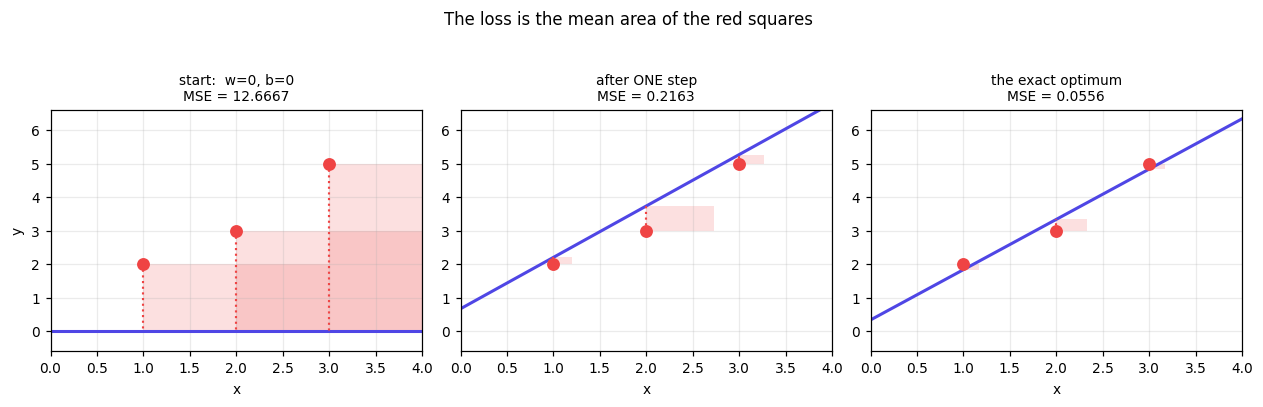

In [2]:
x = np.array(X_DATA)
y = np.array(Y_DATA)
grid = np.linspace(0, 4, 100)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
for ax, (w, b, name) in zip(axes, [
    (0.0, 0.0, "start:  w=0, b=0"),
    (TRUTH["w_1"], TRUTH["b_1"], "after ONE step"),
    (TRUTH["w_star"], TRUTH["b_star"], "the exact optimum"),
]):
    pred = w * x + b
    loss = np.mean((pred - y) ** 2)
    ax.plot(grid, w * grid + b, color="#4f46e5", lw=2, zorder=2)
    ax.scatter(x, y, s=55, color="#ef4444", zorder=4, label="data")
    for xi, yi, pi in zip(x, y, pred):
        side = abs(pi - yi)
        ax.add_patch(plt.Rectangle((xi, min(yi, pi)), side, side,
                                   facecolor="#ef4444", alpha=0.16, zorder=1))
        ax.plot([xi, xi], [yi, pi], color="#ef4444", lw=1.4, ls=":", zorder=3)
    ax.set_title(f"{name}\nMSE = {loss:.4f}", fontsize=9)
    ax.set_xlim(0, 4); ax.set_ylim(-0.6, 6.6)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.suptitle("The loss is the mean area of the red squares", y=1.04)
plt.tight_layout()
plt.show()

### 4.2 The loss surface, and the path down it

With only two parameters the entire loss landscape fits in one picture. This
is a luxury we lose forever after this lesson — a real network's surface
lives in millions of dimensions — so look carefully at what descent is doing.

Note the **elongated, tilted valley**. That shape is why the path zig-zags
instead of heading straight for the minimum, and it comes from $x$ and the
constant 1 being correlated across the data. Lesson 15's optimizers exist
almost entirely to deal with valleys like this.

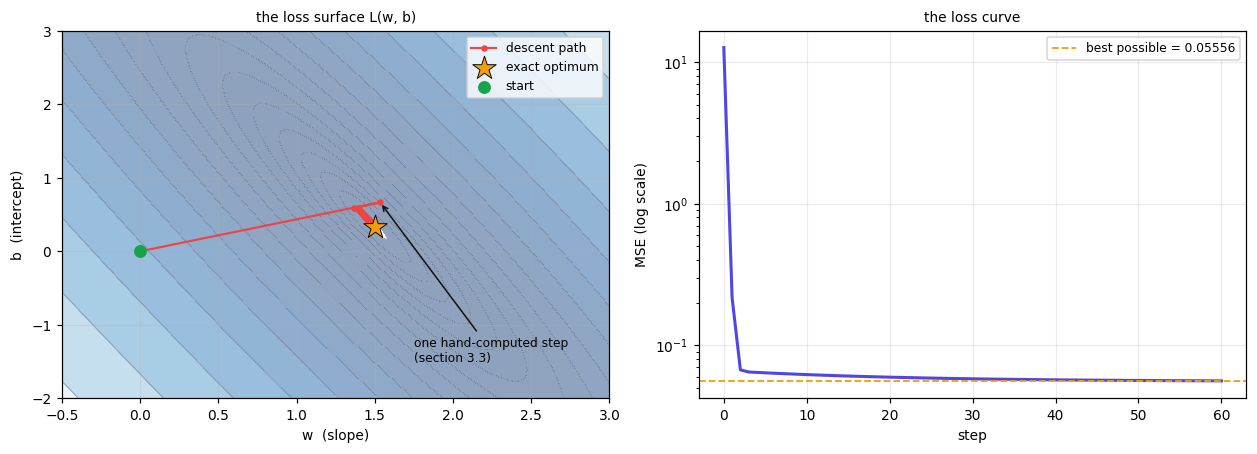

step 0 : loss 12.666667   w=0.00000  b=0.00000
step 1 : loss  0.216296   w=1.53333  b=0.66667   <- matches section 3.3
step 60: loss  0.056135   w=1.47205  b=0.39687
exact  : loss  0.055556   w=1.50000  b=0.33333


In [3]:
def loss_at(w, b):
    return np.mean((w * x[:, None, None] + b - y[:, None, None]) ** 2, axis=0)


def run_gd(w, b, lr, steps):
    """Plain gradient descent. Returns the full trajectory."""
    hist = [(w, b, float(np.mean((w * x + b - y) ** 2)))]
    for _ in range(steps):
        err = (w * x + b) - y
        gw = 2 * np.mean(err * x)
        gb = 2 * np.mean(err)
        w, b = w - lr * gw, b - lr * gb          # both from the SAME old values
        hist.append((w, b, float(np.mean((w * x + b - y) ** 2))))
    return np.array(hist)


W, B = np.meshgrid(np.linspace(-0.5, 3.0, 220), np.linspace(-2.0, 3.0, 220))
Z = loss_at(W, B)
path = run_gd(0.0, 0.0, LR, 60)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.2))

cs = ax0.contour(W, B, Z, levels=np.geomspace(0.06, 60, 18), colors="#94a3b8", linewidths=0.7)
ax0.contourf(W, B, Z, levels=np.geomspace(0.06, 60, 18), cmap="Blues_r", alpha=0.45)
ax0.plot(path[:, 0], path[:, 1], "-o", color="#ef4444", ms=3.2, lw=1.4, label="descent path")
ax0.scatter([TRUTH["w_star"]], [TRUTH["b_star"]], marker="*", s=260,
            color="#f59e0b", edgecolor="black", lw=.6, zorder=5, label="exact optimum")
ax0.scatter([0], [0], s=55, color="#16a34a", zorder=5, label="start")
ax0.annotate("one hand-computed step\n(section 3.3)",
             xy=(TRUTH["w_1"], TRUTH["b_1"]), xytext=(1.75, -1.5), fontsize=8,
             arrowprops=dict(arrowstyle="->", color="#111", lw=1))
ax0.set_xlabel("w  (slope)"); ax0.set_ylabel("b  (intercept)")
ax0.set_title("the loss surface L(w, b)", fontsize=9)
ax0.legend(fontsize=8, loc="upper right")

ax1.plot(path[:, 2], color="#4f46e5", lw=2)
ax1.axhline(TRUTH["loss_star"], color="#f59e0b", ls="--", lw=1.2,
            label=f"best possible = {TRUTH['loss_star']:.5f}")
ax1.set_yscale("log")
ax1.set_xlabel("step"); ax1.set_ylabel("MSE (log scale)")
ax1.set_title("the loss curve", fontsize=9)
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"step 0 : loss {path[0, 2]:9.6f}   w={path[0, 0]:.5f}  b={path[0, 1]:.5f}")
print(f"step 1 : loss {path[1, 2]:9.6f}   w={path[1, 0]:.5f}  b={path[1, 1]:.5f}   <- matches section 3.3")
print(f"step 60: loss {path[-1, 2]:9.6f}   w={path[-1, 0]:.5f}  b={path[-1, 1]:.5f}")
print(f"exact  : loss {TRUTH['loss_star']:9.6f}   w={TRUTH['w_star']:.5f}  b={TRUTH['b_star']:.5f}")

### 4.3 The learning rate is the whole ballgame

Same data, same starting point, same code. Only $\eta$ changes.

For this problem the loss is exactly quadratic, so there is a hard threshold:
descent converges only when $\eta < 2/\lambda_{\max}$, where $\lambda_{\max}$
is the largest eigenvalue of the Hessian. We compute it below — it comes out
at **0.1803**, which is why $\eta = 0.1$ works and $\eta = 0.2$ explodes.

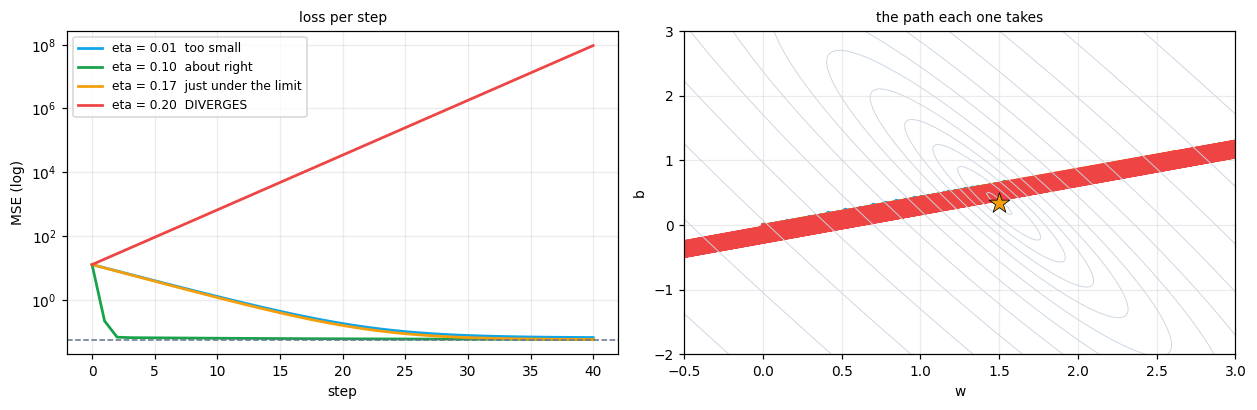

Hessian eigenvalues : [ 0.2404 11.0929]
divergence threshold: eta > 2 / 11.0929 = 0.1803

The ratio of the two eigenvalues is 46.1:1.
That ratio is the CONDITION NUMBER. It is why the valley is a narrow
ellipse rather than a circle, and why the path zig-zags. Lesson 15's
momentum and Adam are, at heart, fixes for a large condition number.


In [4]:
design = np.stack([x, np.ones_like(x)], axis=1)      # columns: x, 1
hessian = 2 / len(x) * design.T @ design
lam_max = np.linalg.eigvalsh(hessian).max()
eta_crit = 2 / lam_max

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.8))
for lr, colour, label in [(0.01, "#0ea5e9", "0.01  too small"),
                          (0.10, "#16a34a", "0.10  about right"),
                          (0.17, "#f59e0b", "0.17  just under the limit"),
                          (0.20, "#ef4444", "0.20  DIVERGES")]:
    h = run_gd(0.0, 0.0, lr, 40)
    finite = np.isfinite(h[:, 2])
    ax0.plot(np.where(finite)[0], h[finite, 2], color=colour, lw=1.8, label=f"eta = {label}")
    ax1.plot(h[finite, 0], h[finite, 1], "-o", color=colour, ms=2.5, lw=1.2)

ax0.set_yscale("log"); ax0.set_xlabel("step"); ax0.set_ylabel("MSE (log)")
ax0.axhline(TRUTH["loss_star"], color="#64748b", ls="--", lw=1)
ax0.set_title("loss per step", fontsize=9); ax0.legend(fontsize=8)

ax1.contour(W, B, Z, levels=np.geomspace(0.06, 60, 14), colors="#cbd5e1", linewidths=0.6)
ax1.scatter([TRUTH["w_star"]], [TRUTH["b_star"]], marker="*", s=200, color="#f59e0b",
            edgecolor="black", lw=.5, zorder=5)
ax1.set_xlim(-0.5, 3.0); ax1.set_ylim(-2.0, 3.0)
ax1.set_xlabel("w"); ax1.set_ylabel("b"); ax1.set_title("the path each one takes", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Hessian eigenvalues : {np.linalg.eigvalsh(hessian).round(4)}")
print(f"divergence threshold: eta > 2 / {lam_max:.4f} = {eta_crit:.4f}")
print(f"\nThe ratio of the two eigenvalues is {np.linalg.eigvalsh(hessian).max() / np.linalg.eigvalsh(hessian).min():.1f}:1.")
print("That ratio is the CONDITION NUMBER. It is why the valley is a narrow")
print("ellipse rather than a circle, and why the path zig-zags. Lesson 15's")
print("momentum and Adam are, at heart, fixes for a large condition number.")

## 5. Scratch code — pure Python, no imports

The complete training loop in about fifteen lines. No arrays, no autodiff,
no framework. Every number in section 3 has to come out of this.

In [5]:
def predict(w, b, xs):
    return [w * xi + b for xi in xs]


def mse(w, b, xs, ys):
    m = len(xs)
    return sum((w * xi + b - yi) ** 2 for xi, yi in zip(xs, ys)) / m


def gradients(w, b, xs, ys):
    """dL/dw = (2/m) sum e_i x_i ;  dL/db = (2/m) sum e_i"""
    m = len(xs)
    errs = [w * xi + b - yi for xi, yi in zip(xs, ys)]
    gw = 2 / m * sum(e * xi for e, xi in zip(errs, xs))
    gb = 2 / m * sum(errs)
    return gw, gb


def train(xs, ys, lr=LR, steps=1, w=0.0, b=0.0, record=False):
    hist = []
    for _ in range(steps):
        gw, gb = gradients(w, b, xs, ys)
        # Both updates use the OLD w and b. Sequencing them would be a
        # different algorithm -- see section 9.
        w, b = w - lr * gw, b - lr * gb
        if record:
            hist.append((w, b, mse(w, b, xs, ys)))
    return (w, b, hist) if record else (w, b)


# --- reproduce section 3 exactly ---------------------------------------
loss_0 = mse(0.0, 0.0, X_DATA, Y_DATA)
gw_0, gb_0 = gradients(0.0, 0.0, X_DATA, Y_DATA)
w_1, b_1 = train(X_DATA, Y_DATA, steps=1)
loss_1 = mse(w_1, b_1, X_DATA, Y_DATA)

print("one step by hand vs. by code")
print(f"  L(0,0)    hand {TRUTH['loss_0']:>11.6f}   code {loss_0:>11.6f}")
print(f"  dL/dw     hand {TRUTH['grad_w']:>11.6f}   code {gw_0:>11.6f}")
print(f"  dL/db     hand {TRUTH['grad_b']:>11.6f}   code {gb_0:>11.6f}")
print(f"  w after 1 hand {TRUTH['w_1']:>11.6f}   code {w_1:>11.6f}")
print(f"  b after 1 hand {TRUTH['b_1']:>11.6f}   code {b_1:>11.6f}")
print(f"  L after 1 hand {TRUTH['loss_1']:>11.6f}   code {loss_1:>11.6f}")

scratch = {"loss_0": loss_0, "grad_w": gw_0, "grad_b": gb_0,
           "w_1": w_1, "b_1": b_1, "loss_1": loss_1}
for k, v in scratch.items():
    assert abs(v - TRUTH[k]) < 1e-12, f"scratch {k}: {v} != {TRUTH[k]}"

# --- and converge to the closed form ------------------------------------
w_end, b_end = train(X_DATA, Y_DATA, steps=4000)
print(f"\nafter 4000 steps:  w = {w_end:.8f}   b = {b_end:.8f}")
print(f"closed form     :  w = {TRUTH['w_star']:.8f}   b = {TRUTH['b_star']:.8f}")
assert abs(w_end - TRUTH["w_star"]) < 1e-6 and abs(b_end - TRUTH["b_star"]) < 1e-6
print("\nGradient descent found the exact answer without ever being told it.")

one step by hand vs. by code
  L(0,0)    hand   12.666667   code   12.666667
  dL/dw     hand  -15.333333   code  -15.333333
  dL/db     hand   -6.666667   code   -6.666667
  w after 1 hand    1.533333   code    1.533333
  b after 1 hand    0.666667   code    0.666667
  L after 1 hand    0.216296   code    0.216296

after 4000 steps:  w = 1.50000000   b = 0.33333333
closed form     :  w = 1.50000000   b = 0.33333333

Gradient descent found the exact answer without ever being told it.


### 5.1 Is the derivation itself right?

Everything above assumed our calculus was correct. Here we check it against
the *definition* of a derivative, with no algebra involved:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + \varepsilon) - L(w - \varepsilon)}{2\varepsilon}$$

This is **gradient checking**, and it is the single most useful debugging
tool in this entire course. Every hand-derived gradient from here to the
transformer gets checked this way.

The standard test is the **relative** error

$$\text{rel} = \frac{|g_{\text{analytic}} - g_{\text{numeric}}|}
                    {|g_{\text{analytic}}| + |g_{\text{numeric}}|}$$

with the usual verdicts: below $10^{-7}$ is excellent, below $10^{-5}$ is
fine, above $10^{-3}$ means your derivation is wrong. Relative, not absolute,
because a gradient of $10^6$ and a gradient of $10^{-6}$ cannot share an
absolute tolerance.

Watch the last row below carefully. **The check gets worse near the
optimum** — not because the calculus degrades, but because
$f(w+\varepsilon) - f(w-\varepsilon)$ becomes a subtraction of two nearly
equal floats, and catastrophic cancellation eats the significant digits. Any
gradient check reports its worst numbers exactly where the gradient is
smallest, which is precisely where you are least likely to care.

A pure ratio is therefore not enough on its own. *At* the optimum both
gradients are genuinely zero — $10^{-16}$ of floating-point noise — and the
ratio divides noise by noise, reporting a relative error near 1 and
condemning perfectly correct code. The working test is **either** criterion:

$$\text{rel} < 10^{-5} \quad\textbf{ or }\quad |g_a - g_n| < 10^{-8}$$

Relative error catches a wrong derivation at any scale; the absolute escape
hatch stops a correct derivation being failed for having nothing left to
measure.

In [6]:
def numeric_grad(f, w, b, eps=1e-6):
    """Central differences -- error O(eps^2), versus O(eps) for a one-sided step."""
    gw = (f(w + eps, b) - f(w - eps, b)) / (2 * eps)
    gb = (f(w, b + eps) - f(w, b - eps)) / (2 * eps)
    return gw, gb


def grad_check(analytic, numeric, rel_tol=1e-5, abs_tol=1e-8):
    """Returns (worst relative error, worst absolute difference, passed)."""
    rel = max(abs(a - n) / max(1e-300, abs(a) + abs(n)) for a, n in zip(analytic, numeric))
    dif = max(abs(a - n) for a, n in zip(analytic, numeric))
    return rel, dif, (rel < rel_tol or dif < abs_tol)


f = lambda w, b: mse(w, b, X_DATA, Y_DATA)

print(f"  {'where':<22} {'rel err':>10} {'abs diff':>11}   verdict")
print("  " + "-" * 58)
for (w0, b0, where) in [(0.0, 0.0, "the starting point"),
                        (-2.0, 4.0, "a badly wrong guess"),
                        (1.4999, 0.3333, "nearly converged"),
                        (1.5, 1 / 3, "exactly AT the optimum")]:
    ga = gradients(w0, b0, X_DATA, Y_DATA)
    gn = numeric_grad(f, w0, b0)
    rel, dif, ok = grad_check(ga, gn)
    print(f"  {where:<22} {rel:>10.2e} {dif:>11.2e}   {'pass' if ok else 'FAIL'}")
    assert ok, "the hand-derived gradient disagrees with the definition"

print("\nThe calculus in section 2.3 is correct.")
print("""
Read the two columns together. The relative error degrades by eight orders of
magnitude as the gradient shrinks, while the absolute difference stays tiny
throughout -- the derivation never got worse, only the measurement did. This
is also why you should gradient-check at a RANDOM untrained parameter rather
than at a converged one.

Deliberately break the derivation to see what a real failure looks like:""")

bad = lambda w, b: (gradients(w, b, X_DATA, Y_DATA)[0] * 0.999,   # 0.1% too small
                    gradients(w, b, X_DATA, Y_DATA)[1])
rel, dif, ok = grad_check(bad(0.0, 0.0), numeric_grad(f, 0.0, 0.0))
print(f"  a gradient 0.1% too small:  rel err {rel:.2e}   verdict {'pass' if ok else 'FAIL'}")
assert not ok, "the check should have caught a 0.1% error"
print("  Caught. A bug this small would be invisible in the loss curve.")

  where                     rel err    abs diff   verdict
  ----------------------------------------------------------
  the starting point       6.99e-11    9.32e-10   pass
  a badly wrong guess      2.03e-10    2.71e-09   pass
  nearly converged         7.01e-08    6.55e-11   pass
  exactly AT the optimum   1.00e+00    2.43e-11   pass

The calculus in section 2.3 is correct.

Read the two columns together. The relative error degrades by eight orders of
magnitude as the gradient shrinks, while the absolute difference stays tiny
throughout -- the derivation never got worse, only the measurement did. This
is also why you should gradient-check at a RANDOM untrained parameter rather
than at a converged one.

Deliberately break the derivation to see what a real failure looks like:
  a gradient 0.1% too small:  rel err 5.00e-04   verdict FAIL
  Caught. A bug this small would be invisible in the loss curve.


## 6. NumPy — vectorized

The loop over samples disappears into a dot product. Same maths, same
numbers, and it is the form that scales to a million rows.

Written with a **design matrix** $X$ whose last column is all ones, the bias
becomes just another weight — which is how every real implementation does it:

$$\hat{y} = X\theta, \qquad \nabla_\theta L = \frac{2}{m} X^{\top}(X\theta - y)$$

In [7]:
X_np = np.array(X_DATA)
y_np = np.array(Y_DATA)
design = np.stack([X_np, np.ones_like(X_np)], axis=1)     # (m, 2): [x, 1]


def np_loss(theta):
    return float(np.mean((design @ theta - y_np) ** 2))


def np_grad(theta):
    m = len(y_np)
    return 2 / m * design.T @ (design @ theta - y_np)      # (2,) = [dL/dw, dL/db]


theta = np.zeros(2)
np_res = {"loss_0": np_loss(theta), "grad_w": np_grad(theta)[0], "grad_b": np_grad(theta)[1]}
theta = theta - LR * np_grad(theta)
np_res |= {"w_1": theta[0], "b_1": theta[1], "loss_1": np_loss(theta)}

for k in ("loss_0", "grad_w", "grad_b", "w_1", "b_1", "loss_1"):
    assert abs(np_res[k] - TRUTH[k]) < 1e-12, f"numpy {k}"
    print(f"  {k:<8} = {np_res[k]:>12.6f}   matches hand calculation")

# train to convergence
theta = np.zeros(2)
for _ in range(4000):
    theta -= LR * np_grad(theta)
print(f"\nafter 4000 steps: w = {theta[0]:.8f}, b = {theta[1]:.8f}")

  loss_0   =    12.666667   matches hand calculation
  grad_w   =   -15.333333   matches hand calculation
  grad_b   =    -6.666667   matches hand calculation
  w_1      =     1.533333   matches hand calculation
  b_1      =     0.666667   matches hand calculation
  loss_1   =     0.216296   matches hand calculation

after 4000 steps: w = 1.50000000, b = 0.33333333


In [8]:
# The closed form, solved directly. No iteration at all.
theta_exact = np.linalg.solve(design.T @ design, design.T @ y_np)
print(f"normal equation : w = {theta_exact[0]:.8f}, b = {theta_exact[1]:.8f}")
print(f"gradient descent: w = {theta[0]:.8f}, b = {theta[1]:.8f}")
print(f"agreement       : {np.allclose(theta, theta_exact, atol=1e-6)}")

assert np.allclose(theta, theta_exact, atol=1e-6)
assert abs(theta_exact[0] - TRUTH["w_star"]) < 1e-12
assert abs(theta_exact[1] - TRUTH["b_star"]) < 1e-12

print("""
So why ever use gradient descent here? You would not -- for linear regression
the closed form wins outright. It is worth being honest about that.

The reason it matters is that the closed form requires inverting a matrix of
size (features x features), and it only exists because the model is linear.
Add one sigmoid (Lesson 08) and no closed form exists at all. Gradient descent
does not care: it only ever needs the gradient. That indifference is what
makes it the one algorithm that scales all the way to a transformer.""")

normal equation : w = 1.50000000, b = 0.33333333
gradient descent: w = 1.50000000, b = 0.33333333
agreement       : True

So why ever use gradient descent here? You would not -- for linear regression
the closed form wins outright. It is worth being honest about that.

The reason it matters is that the closed form requires inverting a matrix of
size (features x features), and it only exists because the model is linear.
Add one sigmoid (Lesson 08) and no closed form exists at all. Gradient descent
does not care: it only ever needs the gradient. That indifference is what
makes it the one algorithm that scales all the way to a transformer.


## 7. TensorFlow

Two versions. First `GradientTape`, which shows the same four lines you wrote
by hand with autodiff supplying the gradients. Then the one-line Keras model,
which is what you would actually ship.

In [9]:
try:
    import tensorflow as tf
    HAS_TF = True
    tf.random.set_seed(0)
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [10]:
if HAS_TF:
    # --- the manual version: same loop, autodiff instead of hand calculus ---
    w_tf = tf.Variable(0.0)
    b_tf = tf.Variable(0.0)
    xt = tf.constant(X_DATA)
    yt = tf.constant(Y_DATA)

    with tf.GradientTape() as tape:
        loss = tf.reduce_mean((w_tf * xt + b_tf - yt) ** 2)
    gw_tf, gb_tf = tape.gradient(loss, [w_tf, b_tf])

    print("TensorFlow's autodiff vs. our hand-derived formulas:")
    print(f"  L(0,0)  {float(loss):>12.6f}   hand {TRUTH['loss_0']:>12.6f}")
    print(f"  dL/dw   {float(gw_tf):>12.6f}   hand {TRUTH['grad_w']:>12.6f}")
    print(f"  dL/db   {float(gb_tf):>12.6f}   hand {TRUTH['grad_b']:>12.6f}")

    w_tf.assign_sub(LR * gw_tf)
    b_tf.assign_sub(LR * gb_tf)
    tf_res = {
        "loss_0": float(loss), "grad_w": float(gw_tf), "grad_b": float(gb_tf),
        "w_1": float(w_tf), "b_1": float(b_tf),
        "loss_1": float(tf.reduce_mean((w_tf * xt + b_tf - yt) ** 2)),
    }
    print(f"  w_1     {tf_res['w_1']:>12.6f}   hand {TRUTH['w_1']:>12.6f}")
    print(f"  b_1     {tf_res['b_1']:>12.6f}   hand {TRUTH['b_1']:>12.6f}")
else:
    tf_res = None

In [11]:
if HAS_TF:
    # --- the Keras version: one Dense unit IS this model -------------------
    model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,))])
    model.set_weights([np.zeros((1, 1)), np.zeros(1)])       # start at w=0, b=0
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=LR), loss="mse")

    hist = model.fit(np.array(X_DATA)[:, None], np.array(Y_DATA),
                     epochs=4000, batch_size=3, verbose=0)
    kw, kb = model.get_weights()
    print(f"Keras Dense(1) after 4000 epochs:  w = {kw[0, 0]:.6f}   b = {kb[0]:.6f}")
    print(f"our hand-derived closed form    :  w = {TRUTH['w_star']:.6f}   b = {TRUTH['b_star']:.6f}")
    print(f"final loss {hist.history['loss'][-1]:.8f}  vs best possible {TRUTH['loss_star']:.8f}")

    assert abs(kw[0, 0] - TRUTH["w_star"]) < 1e-3
    assert abs(kb[0] - TRUTH["b_star"]) < 1e-3
    print("\nThe framework found the same line. It used the same four lines of")
    print("update code you wrote in section 5 -- it just wrote them for you.")

## 8. Agreement check

In [12]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch, "numpy": np_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res

keys = ["loss_0", "grad_w", "grad_b", "w_1", "b_1", "loss_1"]
print(f"{'quantity':<10} " + " ".join(f"{n:>18}" for n in implementations))
print("-" * (11 + 19 * len(implementations)))
for k in keys:
    print(f"{k:<10} " + " ".join(f"{impl[k]:>18.10f}" for impl in implementations.values()))

for name, impl in implementations.items():
    for k in keys:
        assert abs(impl[k] - TRUTH[k]) < 1e-6, f"{name} disagrees on {k}"

skipped = "" if tf_res is not None else "   (tensorflow skipped -- not installed locally)"
print(f"\nAll implementations agree to 1e-6.{skipped}")

quantity     hand (section 3)            scratch              numpy
--------------------------------------------------------------------
loss_0          12.6666666667      12.6666666667      12.6666666667
grad_w         -15.3333333333     -15.3333333333     -15.3333333333
grad_b          -6.6666666667      -6.6666666667      -6.6666666667
w_1              1.5333333333       1.5333333333       1.5333333333
b_1              0.6666666667       0.6666666667       0.6666666667
loss_1           0.2162962963       0.2162962963       0.2162962963

All implementations agree to 1e-6.   (tensorflow skipped -- not installed locally)


## 9. The silent failures — two of them, triggered on purpose

### 9.1 Updating the parameters in sequence instead of together

This is the most common way to get a *plausible but wrong* training loop. It
often still converges, which is what makes it so hard to spot.

In [13]:
def train_wrong(xs, ys, lr=LR, steps=1, w=0.0, b=0.0):
    """WRONG: b's gradient is computed using the already-updated w."""
    m = len(xs)
    for _ in range(steps):
        errs = [w * xi + b - yi for xi, yi in zip(xs, ys)]
        w = w - lr * (2 / m * sum(e * xi for e, xi in zip(errs, xs)))
        errs = [w * xi + b - yi for xi, yi in zip(xs, ys)]      # <-- recomputed, new w
        b = b - lr * (2 / m * sum(errs))
    return w, b


right_1 = train(X_DATA, Y_DATA, steps=1)
wrong_1 = train_wrong(X_DATA, Y_DATA, steps=1)
print(f"after 1 step   correct: w={right_1[0]:.6f}  b={right_1[1]:.6f}   <- matches section 3.3")
print(f"               WRONG  : w={wrong_1[0]:.6f}  b={wrong_1[1]:.6f}")

right_e = train(X_DATA, Y_DATA, steps=4000)
wrong_e = train_wrong(X_DATA, Y_DATA, steps=4000)
print(f"\nafter 4000     correct: w={right_e[0]:.6f}  b={right_e[1]:.6f}")
print(f"               WRONG  : w={wrong_e[0]:.6f}  b={wrong_e[1]:.6f}")
print(f"exact answer         : w={TRUTH['w_star']:.6f}  b={TRUTH['b_star']:.6f}")
print("""
Both converge. Both look fine. On this tiny convex problem the wrong one even
reaches the right answer -- so no test you write on the final numbers would
catch it. What it does not do is match the hand calculation after ONE step,
which is exactly why section 3 exists. Check the first step, not the last.""")

after 1 step   correct: w=1.533333  b=0.666667   <- matches section 3.3
               WRONG  : w=1.533333  b=0.053333

after 4000     correct: w=1.500000  b=0.333333
               WRONG  : w=1.500000  b=0.333333
exact answer         : w=1.500000  b=0.333333

Both converge. Both look fine. On this tiny convex problem the wrong one even
reaches the right answer -- so no test you write on the final numbers would
catch it. What it does not do is match the hand calculation after ONE step,
which is exactly why section 3 exists. Check the first step, not the last.


### 9.2 A learning rate a fraction too large

Not "a bit slower to converge" — catastrophically, exponentially divergent,
and the printed loss goes to `nan` within a few dozen steps.

In [14]:
for lr in (0.17, 0.18, 0.1803, 0.181, 0.20):
    h = run_gd(0.0, 0.0, lr, 200)
    final = h[-1, 2]
    verdict = "converged" if np.isfinite(final) and final < 1 else "DIVERGED"
    shown = f"{final:.6f}" if np.isfinite(final) else "       inf/nan"
    print(f"  eta = {lr:<7} final loss {shown:>14}   {verdict}")

print(f"\nThe threshold is eta = 2/lambda_max = {eta_crit:.4f}, computed in section 4.3.")
print("""
Two lessons hide in that table:

  1. The safe learning rate is a property of YOUR DATA, not a universal
     constant. Rescale x by 10 and the threshold changes by 100.
  2. There is no gentle warning. At 0.1800 it converges; at 0.1810 it
     explodes. In a real network you see a loss curve that looks fine and
     then, one step later, `nan` -- with no clue which step broke it.

This is the single most common cause of a training run that produces nothing.""")

  eta = 0.17    final loss       0.055556   converged
  eta = 0.18    final loss       3.453860   DIVERGED
  eta = 0.1803  final loss      12.947117   DIVERGED
  eta = 0.181   final loss     284.467316   DIVERGED
  eta = 0.2     final loss 277426504419691830310271150219853824.000000   DIVERGED

The threshold is eta = 2/lambda_max = 0.1803, computed in section 4.3.

Two lessons hide in that table:

  1. The safe learning rate is a property of YOUR DATA, not a universal
     constant. Rescale x by 10 and the threshold changes by 100.
  2. There is no gentle warning. At 0.1800 it converges; at 0.1810 it
     explodes. In a real network you see a loss curve that looks fine and
     then, one step later, `nan` -- with no clue which step broke it.

This is the single most common cause of a training run that produces nothing.


In [15]:
# The fix, and a preview of why we standardize features (Lesson 01, Exercise 4).
x_big = np.array([100.0, 200.0, 300.0])        # same data, different units
design_big = np.stack([x_big, np.ones_like(x_big)], axis=1)
h_big = np.linalg.eigvalsh(2 / 3 * design_big.T @ design_big).max()

print(f"x in ones     : max safe eta = {eta_crit:.6f}")
print(f"x in hundreds : max safe eta = {2 / h_big:.10f}")
print(f"\nThe same data in different units needs a learning rate {eta_crit / (2 / h_big):,.0f}x smaller.")
print("Standardizing the features first makes one learning rate work everywhere.")

x in ones     : max safe eta = 0.180295
x in hundreds : max safe eta = 0.0000214282

The same data in different units needs a learning rate 8,414x smaller.
Standardizing the features first makes one learning rate work everywhere.


## 10. Exercises

Work them on paper first. Each `assert` tells you when you are right.
Solutions: `solutions/06-linear-regression-solutions.ipynb`.

In [16]:
# --- Exercise 1 -------------------------------------------------------
# Take the SECOND gradient descent step by hand, starting from the section 3.3
# result w1 = 23/15, b1 = 2/3, with eta = 0.1. Give w2 and b2.
#
#   errors e_i = w1*x_i + b1 - y_i      for x = [1,2,3], y = [2,3,5]
#   dL/dw = (2/3) sum e_i x_i ,  dL/db = (2/3) sum e_i
ex1_w2 = None
ex1_b2 = None

_w2, _b2 = train(X_DATA, Y_DATA, steps=1, w=TRUTH["w_1"], b=TRUTH["b_1"])
assert ex1_w2 is not None and abs(ex1_w2 - _w2) < 1e-4, f"w2 should be {_w2:.6f}"
assert ex1_b2 is not None and abs(ex1_b2 - _b2) < 1e-4, f"b2 should be {_b2:.6f}"
print(f"Ex 1 OK -- w2 = {_w2:.6f}, b2 = {_b2:.6f}. Note b went DOWN this step.")

AssertionError: w2 should be 1.368889

In [17]:
# --- Exercise 2 -------------------------------------------------------
# Derive and implement the gradients for MEAN ABSOLUTE ERROR instead of MSE:
#     L = (1/m) sum |w*x_i + b - y_i|
# Hint: d|u|/du = sign(u), so dL/dw = (1/m) sum sign(e_i) * x_i.
def mae_gradients(w, b, xs, ys):
    return None     # <-- return (gw, gb)


_g = mae_gradients(0.0, 0.0, X_DATA, Y_DATA)
assert _g is not None, "return a (gw, gb) tuple"
assert abs(_g[0] - (-2.0)) < 1e-9, f"dL/dw at (0,0) should be -2.0, got {_g[0]}"
assert abs(_g[1] - (-1.0)) < 1e-9, f"dL/db at (0,0) should be -1.0, got {_g[1]}"
print("Ex 2 OK -- notice MAE's gradient does not shrink as the error shrinks.")
print("         That is why MAE is robust to outliers but converges awkwardly.")

AssertionError: return a (gw, gb) tuple

In [18]:
# --- Exercise 3 -------------------------------------------------------
# Add an outlier and watch MSE get dragged towards it. Fit the closed form to
# x=[1,2,3,4], y=[2,3,5,20] and give w to 4 decimals.
ex3_w = None

_d = np.stack([np.array([1., 2., 3., 4.]), np.ones(4)], axis=1)
_t = np.linalg.solve(_d.T @ _d, _d.T @ np.array([2., 3., 5., 20.]))
assert ex3_w is not None and abs(ex3_w - _t[0]) < 1e-3, f"w should be {_t[0]:.4f}"
print(f"Ex 3 OK -- slope moved from 1.5000 to {_t[0]:.4f} because of ONE point.")

AssertionError: w should be 5.6000

In [19]:
# --- Exercise 4 -------------------------------------------------------
# Implement gradient descent that stops early when it has converged: halt as
# soon as the loss improves by less than `tol` in a step. Return (w, b, steps).
def train_until_converged(xs, ys, lr=LR, tol=1e-12, max_steps=100000):
    return None     # <-- (w, b, steps_taken)


_r = train_until_converged(X_DATA, Y_DATA)
assert _r is not None and len(_r) == 3, "return (w, b, steps)"
assert abs(_r[0] - TRUTH["w_star"]) < 1e-4, f"w should reach ~1.5, got {_r[0]}"
assert abs(_r[1] - TRUTH["b_star"]) < 1e-4, f"b should reach ~0.3333, got {_r[1]}"
assert 0 < _r[2] < 100000, "should stop before max_steps"
print(f"Ex 4 OK -- converged in {_r[2]} steps to w={_r[0]:.6f}, b={_r[1]:.6f}")

AssertionError: return (w, b, steps)

In [20]:
# --- Exercise 5 -------------------------------------------------------
# Predict, WITHOUT running it: if every y value is doubled, what happens to
# the optimal w and b? Give the new values for y = [4, 6, 10].
ex5_w = None
ex5_b = None

assert ex5_w is not None and abs(ex5_w - 3.0) < 1e-9, "think about linearity"
assert ex5_b is not None and abs(ex5_b - 2 / 3) < 1e-9
print("Ex 5 OK -- the fit is linear in y, so both parameters simply double.")
print("         Doubling x instead would NOT double w. Work out why.")

AssertionError: think about linearity

In [21]:
# --- Exercise 6 (stretch) ---------------------------------------------
# Generalize to MULTIPLE features using the design-matrix form:
#     grad = (2/m) X^T (X @ theta - y)
# Fit 3 features + bias to 50 random samples and check against the normal
# equation to 1e-6.
def fit_multi(X, y, lr=0.05, steps=20000):
    """X: (m, n) features WITHOUT a bias column. Return theta of length n+1."""
    return None     # <-- your code


np.random.seed(1)
_X = np.random.randn(50, 3)
_true = np.array([2.0, -1.0, 0.5, 3.0])                    # w1, w2, w3, bias
_y = _X @ _true[:3] + _true[3] + 0.01 * np.random.randn(50)

_theta = fit_multi(_X, _y)
assert _theta is not None and len(_theta) == 4, "return 4 parameters"
_Xb = np.hstack([_X, np.ones((50, 1))])
_exact = np.linalg.solve(_Xb.T @ _Xb, _Xb.T @ _y)
assert np.allclose(_theta, _exact, atol=1e-6), f"got {_theta}, exact {_exact}"
print(f"Ex 6 OK -- recovered {np.round(_theta, 3)} vs true {_true}")
print("         You have just written the general linear model. Lesson 10")
print("         stacks two of these with a nonlinearity between them.")

AssertionError: return 4 parameters

## 11. What you learned

- **A linear model is one neuron**, and training it is the loop every network
  uses: predict, measure, differentiate, step, repeat.
- **The MSE gradients are worth remembering by shape, not by symbol:**
  $\partial L/\partial b$ is the average error, and $\partial L/\partial w$ is
  the average error *weighted by the input*. Every later gradient has this
  same "error times input" form — including backprop's.
- **Update all parameters from the same old values.** Sequencing them still
  converges on easy problems, which is precisely what makes it dangerous.
  Checking against a hand-computed *first* step catches it; checking the final
  answer does not.
- **Gradient checking against the definition of a derivative** is how you
  verify calculus you did by hand. We will use it in every remaining lesson.
- **The learning rate has a hard threshold**, $2/\lambda_{\max}$, set by your
  data rather than by convention. Below it, descent converges; a hair above
  it, everything becomes `nan`. Rescaling the inputs moves the threshold,
  which is the practical argument for standardizing features.
- **The closed form beats gradient descent here** — and that honesty matters.
  Gradient descent earns its place from Lesson 08 onwards, when adding a
  single nonlinearity destroys the closed form and leaves it the only option.

### Next

**Lesson 07 — Loss Surfaces and MSE.** We stay with two parameters a little
longer and study the bowl itself: what makes it steep, what makes it narrow,
why the condition number predicts how badly descent will zig-zag, and what a
non-convex surface looks like once we add a nonlinearity.